In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

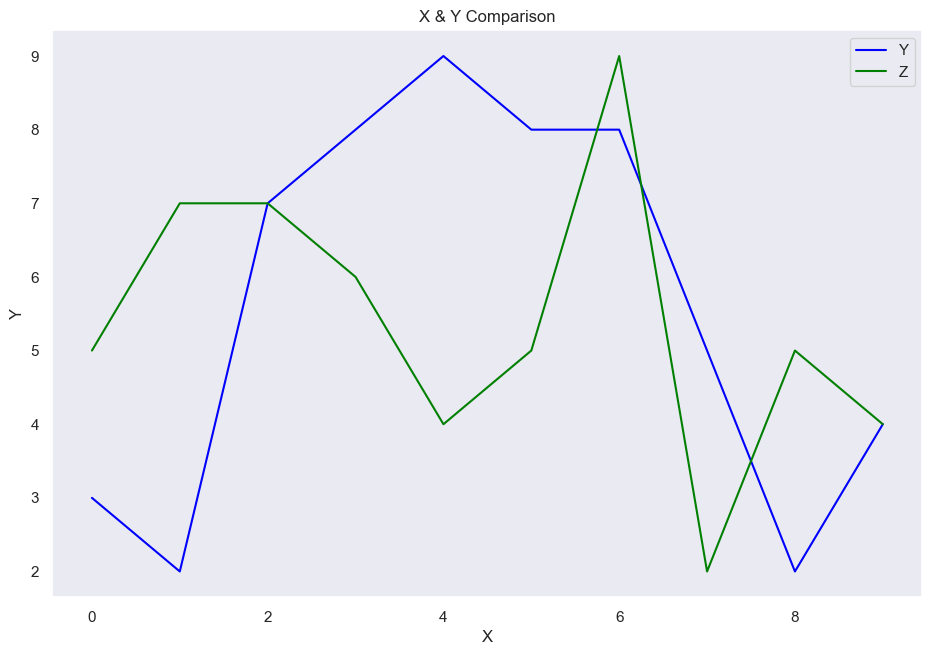

In [26]:
x = np.arange(10)
y = np.random.randint(1,10, size=10)
z = np.random.randint(1,10, size=10)

plt.figure(figsize=(10,7))
plt.plot(x,y,color='blue', label='Y')
plt.plot(x,z,color='green', label='Z')
plt.title("X & Y Comparison")
plt.xlabel("X")
plt. ylabel("Y")
plt.legend()
#plt.xlim([-5, 12])
plt.grid()
plt.show()

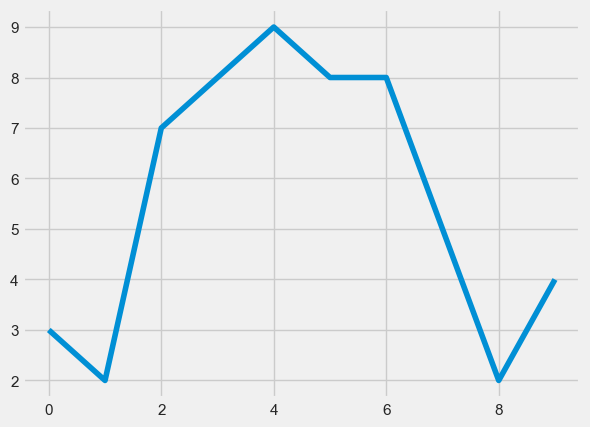

In [27]:
plt.style.use('fivethirtyeight')
plt.plot(x,y)

In [28]:
import kagglehub

path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\kiril\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [29]:
data = pd.read_csv(r"C:\Users\kiril\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1\Titanic-Dataset.csv", index_col='PassengerId')

In [30]:
df = pd.DataFrame(data)

In [31]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<BarContainer object of 11 artists>

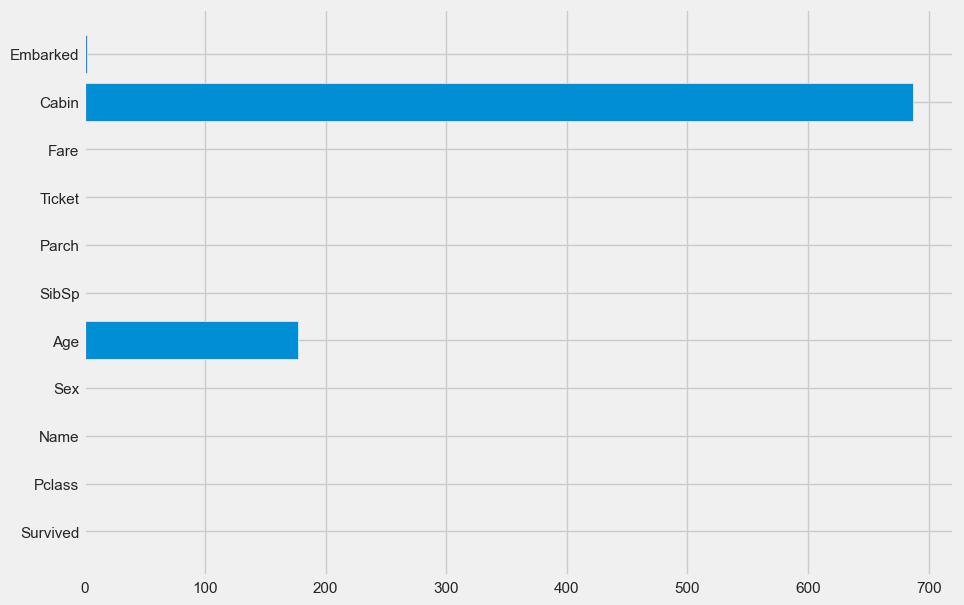

In [32]:
p = df.isna().sum(axis=0)
plt.figure(figsize=(10,7))
plt.barh(p.index, p.values)

<BarContainer object of 3 artists>

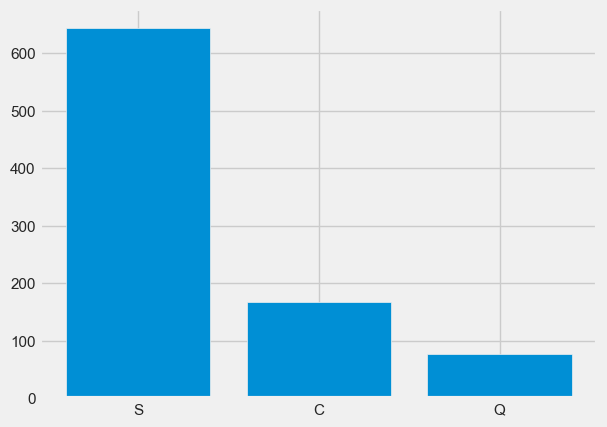

In [33]:
m = df['Embarked'].value_counts()
plt.bar(m.index, m.values)

In [34]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [35]:
mean_Age = np.mean(df['Age'].dropna().values)
median_Age = np.quantile(df['Age'].dropna().values, q=0.5)
print(f"mean_Age ={mean_Age}")
print(f"median_Age = {median_Age}")

mean_Age =29.69911764705882
median_Age = 28.0


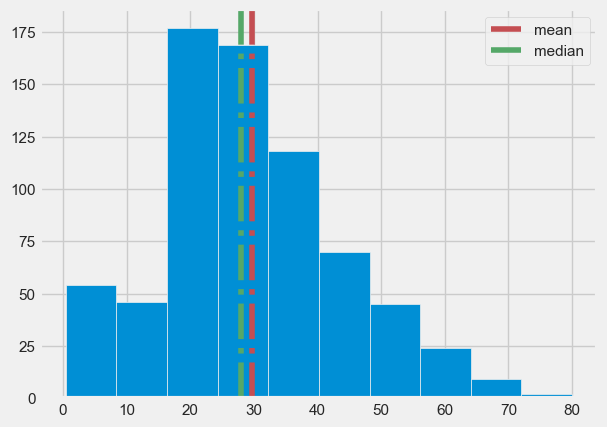

In [36]:
plt.hist(df['Age'])

plt.axvline(x=mean_Age, color='r', linestyle='-.', label='mean')
plt.axvline(x=median_Age, color='g', linestyle='-.', label='median')
plt.legend()
plt.show()

In [37]:
df.dropna(inplace=True)

In [38]:
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

In [39]:
df['Name']

PassengerId
2      Cumings, Mrs. John Bradley (Florence Briggs Th...
4           Futrelle, Mrs. Jacques Heath (Lily May Peel)
7                                McCarthy, Mr. Timothy J
11                       Sandstrom, Miss. Marguerite Rut
12                              Bonnell, Miss. Elizabeth
                             ...                        
872     Beckwith, Mrs. Richard Leonard (Sallie Monypeny)
873                             Carlsson, Mr. Frans Olof
880        Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)
888                         Graham, Miss. Margaret Edith
890                                Behr, Mr. Karl Howell
Name: Name, Length: 183, dtype: object

In [40]:
df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(df['Title'], df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,1
Countess,1,0
Dr,1,2
Lady,1,0
Major,0,2
Master,0,7
Miss,44,0
Mlle,2,0


In [41]:
df['Title'] = df['Title'].replace(['Dr', 'Major', 'Capt', 'Col', 'Countess', 'Sir'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Mme', 'Lady', 'Miss'], 'Mrs')

In [42]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,Mrs
12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,Mrs


In [43]:
 df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,1.000000
1,Mr,0.370370
2,Mrs,0.930233
3,Rare,0.666667


In [44]:
df.drop(columns=['Cabin','Name','Ticket'], inplace=True)

In [45]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
2,1,1,female,38.0,1,0,71.2833,C,Mrs
4,1,1,female,35.0,1,0,53.1000,S,Mrs
7,0,1,male,54.0,0,0,51.8625,S,Mr
11,1,3,female,4.0,1,1,16.7000,S,Mrs
12,1,1,female,58.0,0,0,26.5500,S,Mrs


In [46]:
df['Survived'].value_counts()

Survived
1    123
0     60
Name: count, dtype: int64

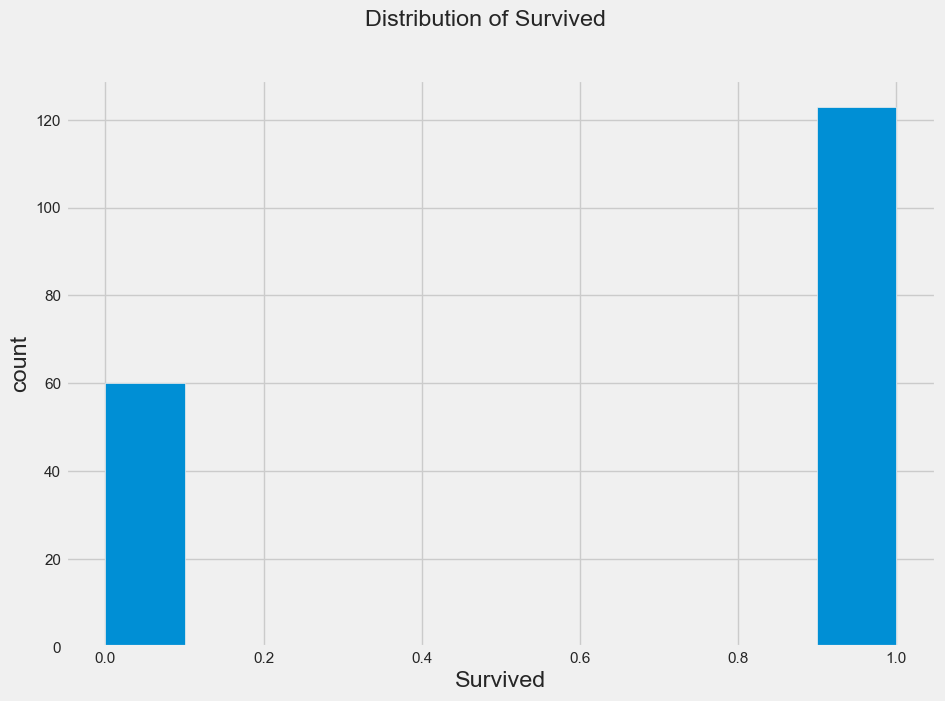

In [47]:
plt.figure(figsize=(10,7))

df['Survived'].hist()
plt.ylabel('count')
plt.xlabel('Survived')

plt.suptitle('Distribution of Survived')
plt.show()

In [48]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title'],
      dtype='object')

In [49]:
categorical_columns = ['Pclass', 'Sex','SibSp', 'Parch','Embarked', 'Title']

In [50]:
categorical_features = df[categorical_columns]

In [51]:
categorical_features

,Pclass,Sex,SibSp,Parch,Embarked,Title
PassengerId,,,,,,
2,1,female,1,0,C,Mrs
4,1,female,1,0,S,Mrs
7,1,male,0,0,S,Mr
11,3,female,1,1,S,Mrs
12,1,female,0,0,S,Mrs
...,...,...,...,...,...,...
872,1,female,1,1,S,Mrs
873,1,male,0,0,S,Mr
880,1,female,0,1,C,Mrs


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 2 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  183 non-null    int64  
 1   Pclass    183 non-null    int64  
 2   Sex       183 non-null    object 
 3   Age       183 non-null    float64
 4   SibSp     183 non-null    int64  
 5   Parch     183 non-null    int64  
 6   Fare      183 non-null    float64
 7   Embarked  183 non-null    object 
 8   Title     183 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 14.3+ KB


In [53]:
unprocessed_cat_features = categorical_features.select_dtypes(include=[object]).columns.tolist()

In [54]:
"""unprocessed_cat_features
unprocessed_cat_features = ['Sex', 'Embarked', 'Title']"""

"unprocessed_cat_features\nunprocessed_cat_features = ['Sex', 'Embarked', 'Title']"

In [55]:
 df.Title.unique()

array(['Mrs', 'Mr', 'Master', 'Rare'], dtype=object)

In [56]:
one_hot = pd.get_dummies(df['Title'])

df_one_hot = pd.concat([df, one_hot], axis=1)

In [57]:
df_one_hot.drop(columns=['Title'], inplace = True)

In [58]:
df_one_hot

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Master,Mr,Mrs,Rare
PassengerId,,,,,,,,,,,,
2,1,1,female,38.0,1,0,71.2833,C,False,False,True,False
4,1,1,female,35.0,1,0,53.1000,S,False,False,True,False
7,0,1,male,54.0,0,0,51.8625,S,False,True,False,False
11,1,3,female,4.0,1,1,16.7000,S,False,False,True,False
12,1,1,female,58.0,0,0,26.5500,S,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,female,47.0,1,1,52.5542,S,False,False,True,False
873,0,1,male,33.0,0,0,5.0000,S,False,True,False,False
880,1,1,female,56.0,0,1,83.1583,C,False,False,True,False


In [59]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

one_hot_encoded = encoder.fit_transform(df[unprocessed_cat_features]).toarray()

one_hot_df = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(unprocessed_cat_features), index=df.index)

In [60]:
one_hot_encoded

array([[1., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 1., ..., 1., 0., 0.]])

In [61]:
one_hot_df

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Mr,Title_Mrs,Title_Rare
PassengerId,,,,,,,,,
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
11,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
12,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
872,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
873,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
880,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [62]:
df_one_hot = pd.concat([df, one_hot_df], axis=1)
df_one_hot

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Mr,Title_Mrs,Title_Rare
PassengerId,,,,,,,,,,,,,,,,,,
2,1,1,female,38.0,1,0,71.2833,C,Mrs,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,1,female,35.0,1,0,53.1000,S,Mrs,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,0,1,male,54.0,0,0,51.8625,S,Mr,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
11,1,3,female,4.0,1,1,16.7000,S,Mrs,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
12,1,1,female,58.0,0,0,26.5500,S,Mrs,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,female,47.0,1,1,52.5542,S,Mrs,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
873,0,1,male,33.0,0,0,5.0000,S,Mr,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
880,1,1,female,56.0,0,1,83.1583,C,Mrs,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [63]:
df_one_hot.drop(columns=unprocessed_cat_features, inplace=True)
df_one_hot

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Mr,Title_Mrs,Title_Rare
PassengerId,,,,,,,,,,,,,,,
2,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,0,1,54.0,0,0,51.8625,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
11,1,3,4.0,1,1,16.7000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
12,1,1,58.0,0,0,26.5500,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,47.0,1,1,52.5542,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
873,0,1,33.0,0,0,5.0000,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
880,1,1,56.0,0,1,83.1583,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [64]:
#LabelEncoding↓

In [65]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for column in unprocessed_cat_features:
    df[column] = label_encoder.fit_transform(df[column])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
2,1,1,0,38.0,1,0,71.2833,0,2
4,1,1,0,35.0,1,0,53.1000,2,2
7,0,1,1,54.0,0,0,51.8625,2,1
11,1,3,0,4.0,1,1,16.7000,2,2
12,1,1,0,58.0,0,0,26.5500,2,2


In [66]:
df.Title.unique()

array([2, 1, 0, 3])

In [67]:
num_columns = ['Age', 'Fare']
num_features = df[num_columns]

print(f"Количество количественных признаков: {len(num_features.columns)}")

Количество количественных признаков: 2


In [68]:
num_features

,Age,Fare
PassengerId,,
2,38.0,71.2833
4,35.0,53.1000
7,54.0,51.8625
11,4.0,16.7000
12,58.0,26.5500
...,...,...
872,47.0,52.5542
873,33.0,5.0000
880,56.0,83.1583


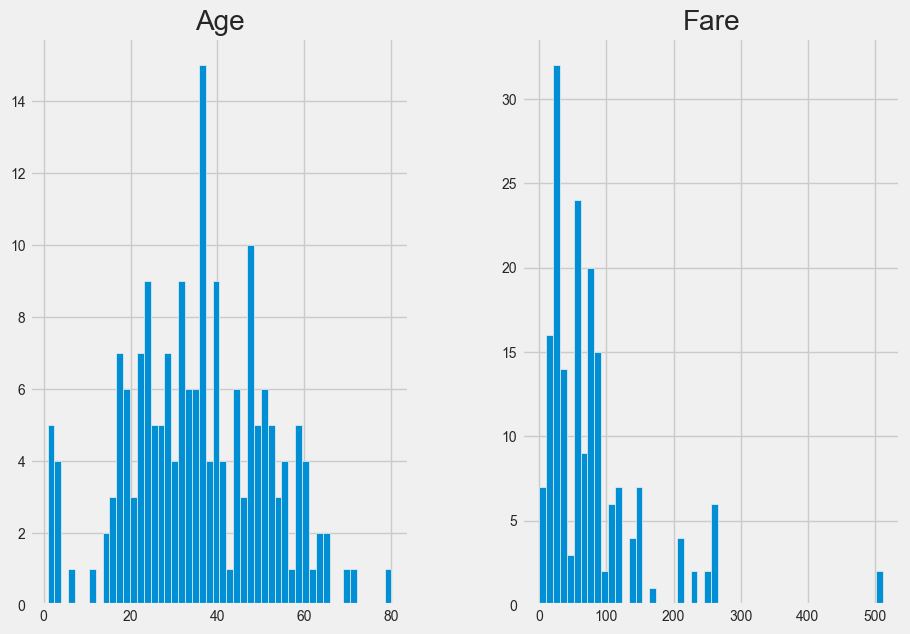

In [69]:
num_features.hist(figsize=(10,7), bins=50, xlabelsize=10, ylabelsize=10);

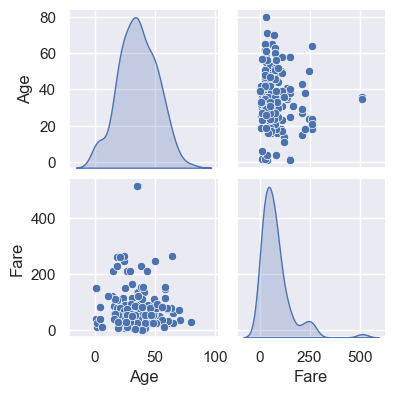

In [70]:
sns.set()
sns.pairplot(df[num_columns], height=2, kind='scatter', diag_kind='kde')
plt.show()

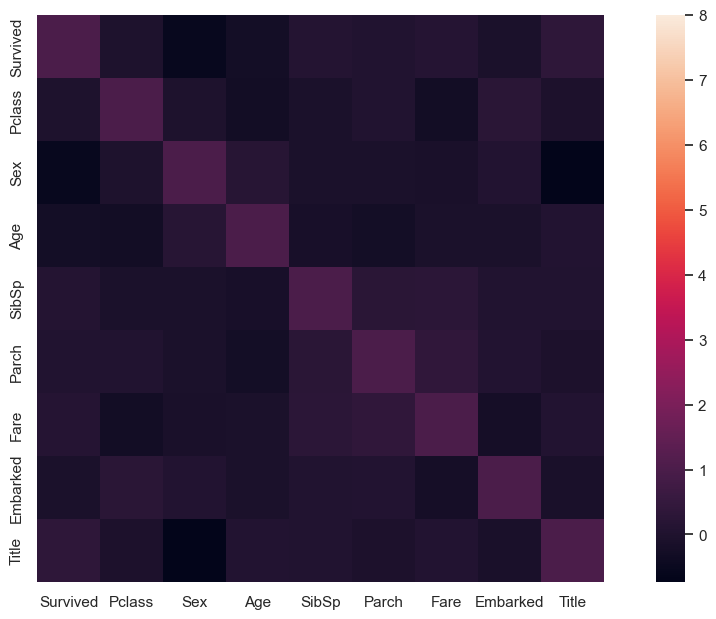

In [71]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12,7))
sns.heatmap(corrmat, vmax=8, square=True);

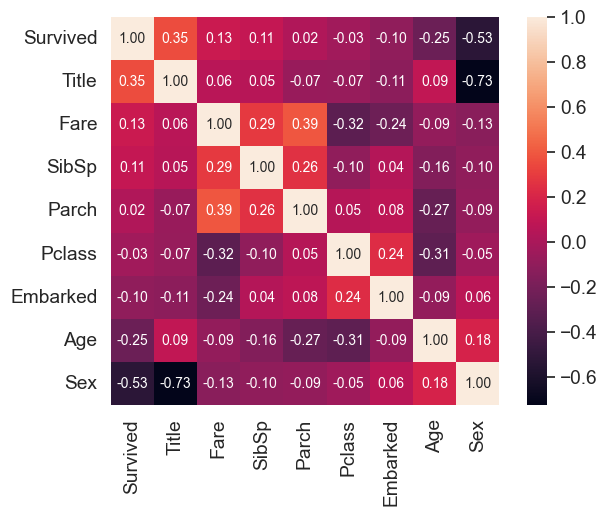

In [72]:
k = 10
cols = corrmat.nlargest(k, 'Survived')['Survived'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [73]:
#Анализ влияния признаков на целевую переменную(Survived)↓

In [74]:
df['Survived'].value_counts()

Survived
1    123
0     60
Name: count, dtype: int64

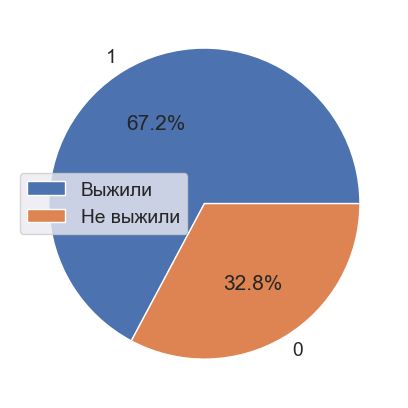

In [75]:
data = df['Survived'].value_counts()

plt.pie(data,labels=data.index, autopct='%1.1f%%')

plt.legend(["Выжили", "Не выжили"])

plt.show()

In [76]:
pd.DataFrame(df.loc[(df.Pclass == 1)]['Survived'].value_counts())

,count
Survived,
1,106
0,52


In [77]:
data.values

array([123,  60])

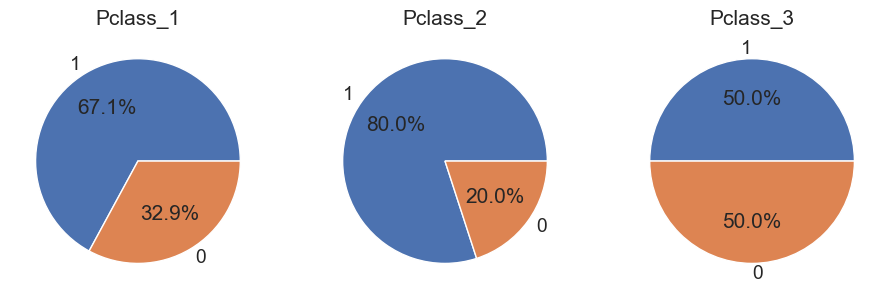

In [78]:
data1 = df.loc[(df.Pclass == 1)]['Survived'].value_counts()
data2 = df.loc[(df.Pclass == 2)]['Survived'].value_counts()
data3 = df.loc[(df.Pclass == 3)]['Survived'].value_counts()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10,7))

ax1.pie(data1.values, labels=data1.index, autopct='%1.1f%%')
ax2.pie(data2.values, labels=data2.index, autopct='%1.1f%%')
ax3.pie(data3.values, labels=data3.index, autopct='%1.1f%%')

ax1.set_title('Pclass_1')
ax2.set_title('Pclass_2')
ax3.set_title('Pclass_3')

plt.show()

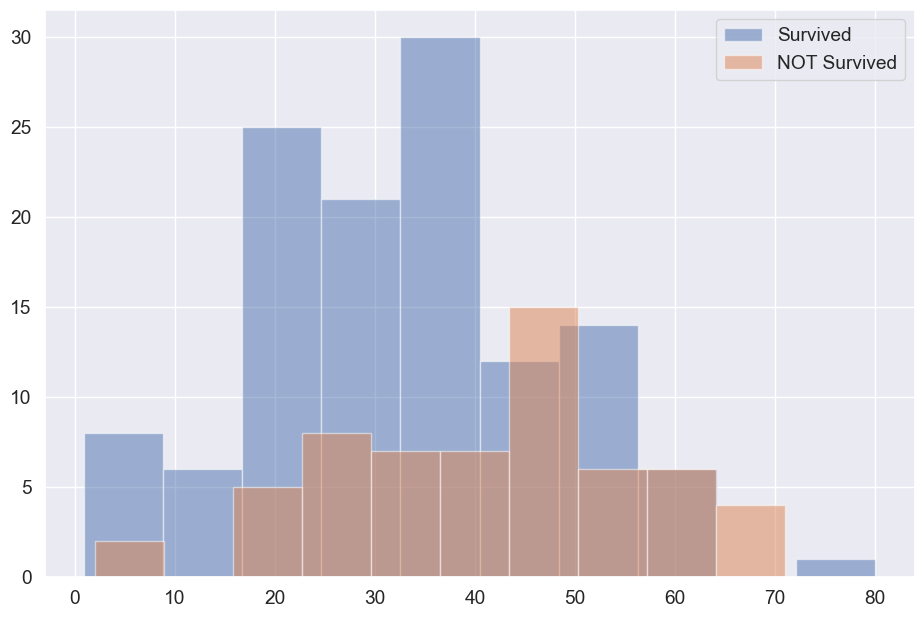

In [79]:
plt.figure(figsize=(10,7))

plt.hist(df.loc[(df.Survived == 1)]['Age'], alpha=0.5, label='Survived')
plt.hist(df.loc[(df.Survived == 0)]['Age'], alpha=0.5, label='NOT Survived')

plt.legend()

plt.show()

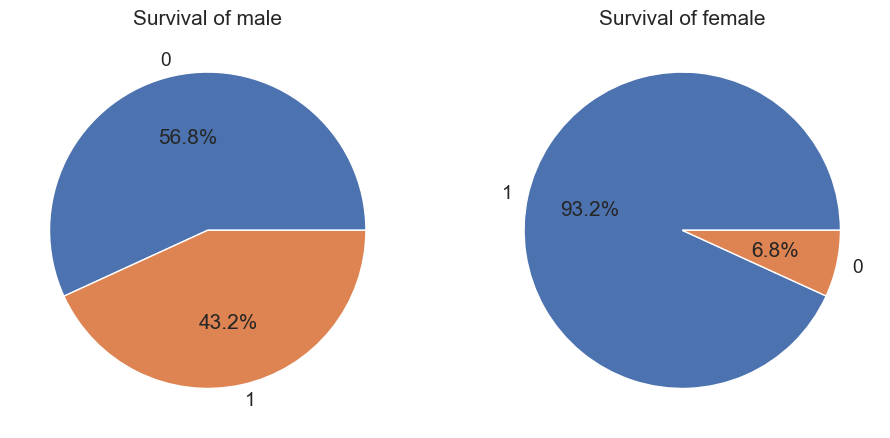

In [80]:
data1 = df.loc[(df.Sex == 1)]['Survived'].value_counts()
data2 = df.loc[(df.Sex == 0)]['Survived'].value_counts()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,7))

ax1.pie(data1.values, labels=data1.index, autopct='%1.1f%%')
ax2.pie(data2.values, labels=data2.index, autopct='%1.1f%%')

ax1.set_title('Survival of male')
ax2.set_title('Survival of female')

plt.show()

In [81]:
data1 = df.loc[(df.Survived == 1)]['Fare']
data2 = df.loc[(df.Survived == 0)]['Fare']

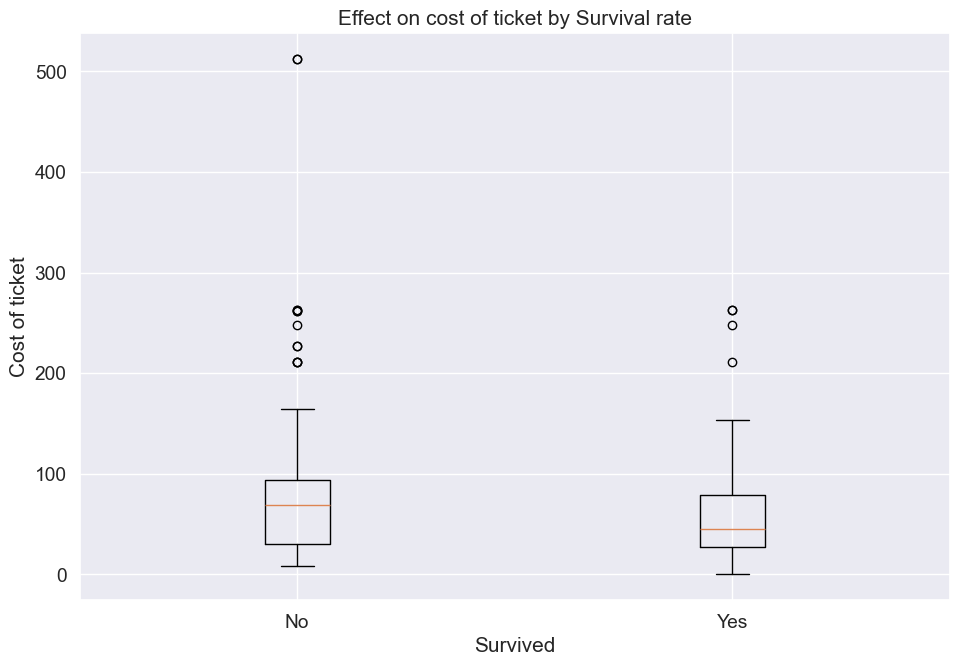

In [82]:
plt.figure(figsize=(10,7))

plt.boxplot([data1, data2])
plt.title('Effect on cost of ticket by Survival rate')
plt.xlabel('Survived')
plt.ylabel('Cost of ticket')
plt.xticks([1,2], ['No','Yes'])

plt.show()

In [83]:
first_quartile = np.quantile(df['Fare'].values, q=0.25)
third_quartile = np.quantile(df['Fare'].values, q=0.75)
print(f"first quartile: {first_quartile}")
print(f"third quartile: {third_quartile}")

first quartile: 29.7
third quartile: 90.0


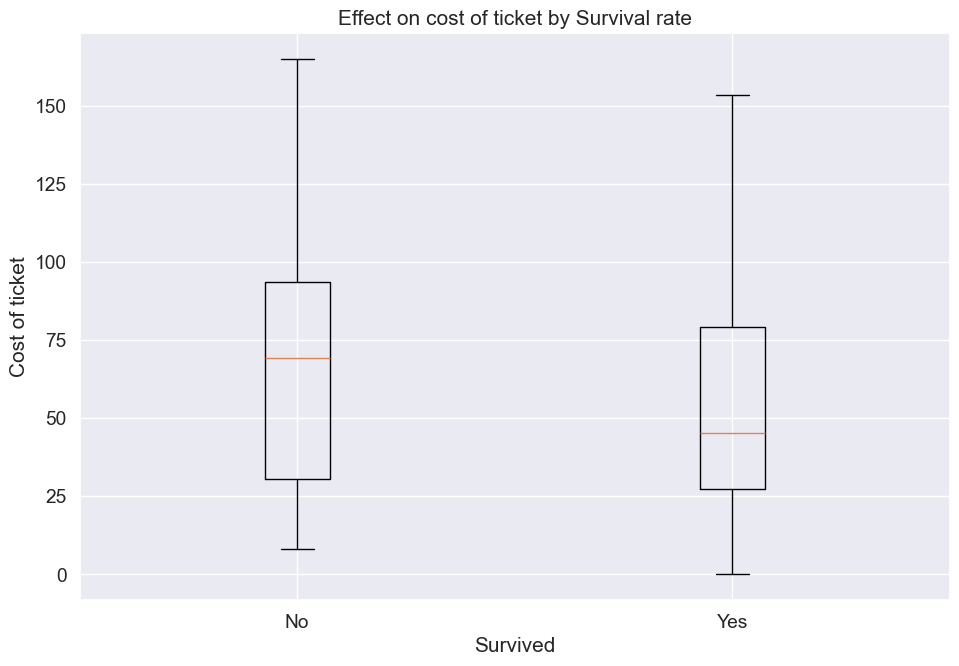

In [84]:
plt.figure(figsize=(10,7))

plt.boxplot([data1, data2], showfliers=False)
plt.title('Effect on cost of ticket by Survival rate')
plt.xlabel('Survived')
plt.ylabel('Cost of ticket')
plt.xticks([1,2], ['No','Yes'])

plt.show()

In [85]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
2,1,1,0,38.0,1,0,71.2833,0,2
4,1,1,0,35.0,1,0,53.1000,2,2
7,0,1,1,54.0,0,0,51.8625,2,1
11,1,3,0,4.0,1,1,16.7000,2,2
12,1,1,0,58.0,0,0,26.5500,2,2


In [86]:
X = df.drop(columns=['Survived']).values
y = df['Survived'].values

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, shuffle=True)

In [89]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [91]:
print("Befor massing: {}".format(X_train.mean(axis=0)))
print("After massing: {}".format(X_train_scaled.mean(axis=0)))

Befor massing: [ 1.20547945  0.52739726 34.45150685  0.46575342  0.46575342 77.22731233
  1.26712329  1.52739726]
After massing: [ 7.68030996e-17  2.93524717e-16  1.55127053e-16  5.39902978e-17
 -3.95421899e-17  1.37257025e-16  6.08341383e-18 -1.58168760e-16]


In [92]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
print("Befor massing: {}".format(X_train.mean(axis=0)))
print("After massing: {}".format(X_train_scaled.mean(axis=0)))

Befor massing: [ 1.20547945  0.52739726 34.45150685  0.46575342  0.46575342 77.22731233
  1.26712329  1.52739726]
After massing: [0.10273973 0.52739726 0.4784747  0.15525114 0.23287671 0.15073767
 0.63356164 0.50913242]


In [109]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abrambeyer/openintro-possum")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kiril\.cache\kagglehub\datasets\abrambeyer\openintro-possum\versions\1


In [110]:
dm = pd.read_csv(r"C:\Users\kiril\.cache\kagglehub\datasets\abrambeyer\openintro-possum\versions\1\possum.csv")
dm.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [111]:
dm.drop(columns=['case','site','Pop'], inplace=True)

In [112]:
dm['sex'] = label_encoder.fit_transform(dm['sex']) # male - 1, female - 0
dm.head()

,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,0,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,0,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,0,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,0,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [113]:
dm.isna().sum()

sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [114]:
dm.dropna(inplace=True)

In [115]:
X = dm.drop(columns=['age']).values
y = dm['age'].values

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X,y,shuffle=True, test_size=0.2, random_state=44)

In [117]:
X_train[0]

array([ 0. , 91. , 55. , 84.5, 36. , 72.8, 51.4, 13.6, 27. , 30. ])

In [118]:
X_test[0]

array([ 1. , 94.5, 64.2, 91. , 39. , 66.5, 46.4, 14.4, 30.5, 33. ])

In [119]:
from math import sqrt

def euclidean_distance_dummy(vec1, vec2):
    distance = 0.0
    for i in range(len(vec1)):
        distance += (vec1[i] - vec2[i])**2
    return sqrt(distance)

In [120]:
euclidean_distance_dummy(X_train[0], X_test[0])

15.353175567289004

In [121]:
X_train[:5]

array([[ 0. , 91. , 55. , 84.5, 36. , 72.8, 51.4, 13.6, 27. , 30. ],
       [ 0. , 93.1, 54.8, 90.5, 35.5, 73.2, 53.6, 14.2, 30. , 32. ],
       [ 0. , 88.7, 52. , 83. , 38. , 61.5, 45.9, 14.7, 26. , 34. ],
       [ 1. , 97.6, 61. , 93.5, 40. , 67.9, 44.3, 15.8, 28.5, 32.5],
       [ 1. , 91.6, 56.6, 88.5, 37.5, 64.5, 45.4, 14.9, 27. , 31. ]])

In [124]:
def get_neighbors_dummy(train, test_row, num_neighbors):
    distances = []
    for train_id, train_row in enumerate(train):
        dist = euclidean_distance_dummy(train_row, test_row)
        distances.append((train_id, dist))

    distances.sort(key= lambda x: x[1])

    nearest_neighbors_ids = []
    for i in range(num_neighbors):
        nearest_neighbors_ids.append(distances[i][0])
    return nearest_neighbors_ids

In [125]:
get_neighbors_dummy(X_train[:5], X_test[1], 3)

[4, 2, 3]

In [126]:
def predict_dummy(X_train, X_test, y_train, num_neighbors=3):
    y_predict = []
    for x_test in X_test:
        nearest_neighbors_ids = get_neighbors_dummy(X_train, x_test, num_neighbors)
        y_preds = y_train[nearest_neighbors_ids]
        y_preds = y_preds.mean()
        y_predict.append(y_preds)

    return y_predict

In [127]:
y_p =  predict_dummy(X_train[:30], X_test[:5], y_train[:30], num_neighbors=5)
y_p

[np.float64(4.4),
 np.float64(3.4),
 np.float64(2.8),
 np.float64(3.4),
 np.float64(3.4)]

In [128]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = np.array([[1, 2],
                 [2, 3],
                 [3, 4],
                 [4, 5]])

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)
print("Нормализованные данные:")
print(normalized_data)

scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)
print("Стандартизованные данные:")
print(standardized_data)

Нормализованные данные:
[[0.         0.        ]
 [0.33333333 0.33333333]
 [0.66666667 0.66666667]
 [1.         1.        ]]
Стандартизованные данные:
[[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]


In [131]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [132]:
y_pred

array([4.4, 4. , 3.2, 5.8, 4. , 4. , 4.6, 2.4, 4.6, 3.8, 2. , 5. , 3. ,
       5.2, 5.8, 4.6, 2.2, 2.8, 4.8, 1.6, 3. ])